# Libraries

In [95]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text
from urllib.parse import quote_plus

In [96]:
path = os.path.join("data","cleaned","final_dataset.csv") 
df=pd.read_csv(path)

## Single product Analysis

In [97]:
df.head()

,order_id,order_date,order_year,order_month,order_day,order_hour,order_minute,order_second,is_weekend,order_status,...,installment_plan,shipping_method,shipping_cost_usd,delivery_days,shipping_country,warehouse_location,delivery_status,device_type,warehouse_id,inventory_id
0,ORD-XAJI00,2024-10-14,2024,10,14,11,20,5,No,Completed,...,No,Economy,1.97,5,Netherlands,EU-Central,In Transit,Mobile,20748,402
1,ORD-NHJ7X0,2024-10-21,2024,10,21,0,49,44,No,Completed,...,Yes,Next Day,5.48,3,United States,USA-East,Delivered,Desktop,41024,507
2,ORD-YTJXE0,2025-03-17,2025,3,17,19,49,36,No,Completed,...,No,Economy,20.40,13,France,EU-Central,In Transit,Tablet,20435,402
3,ORD-EIMVI0,2024-09-27,2024,9,27,6,24,44,No,Completed,...,No,Express,4.76,8,Italy,EU-Central,Delivered,Mobile,20630,513
4,ORD-OR56F0,2025-05-21,2025,5,21,17,10,48,No,Completed,...,No,Standard,15.48,7,Germany,EU-Central,Delivered,Tablet,20505,216


In [98]:
df1=df[df['product_id']==5]

In [99]:
df1.product_name.unique()

array(['Screen Protector Tempered Glass'], dtype=object)

In [100]:
df1['order_date'] = pd.to_datetime(df1['order_date'])

C:\Users\USER\AppData\Local\Temp\ipykernel_11584\2973792906.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['order_date'] = pd.to_datetime(df1['order_date'])


In [101]:
df1.columns

Index(['order_id', 'order_date', 'order_year', 'order_month', 'order_day',
       'order_hour', 'order_minute', 'order_second', 'is_weekend',
       'order_status', 'customer_id', 'customer_name', 'gender', 'age',
       'customer_segment', 'country', 'city', 'customer_loyalty_score',
       'total_orders_by_customer', 'account_creation_date', 'product_id',
       'product_name', 'category', 'sub_category', 'brand',
       'product_rating_avg', 'product_reviews_count', 'stock_quantity',
       'unit_price_usd', 'quantity', 'discount_percent', 'total_price_usd',
       'cost_usd', 'profit_usd', 'tax_usd', 'payment_method', 'payment_status',
       'installment_plan', 'shipping_method', 'shipping_cost_usd',
       'delivery_days', 'shipping_country', 'warehouse_location',
       'delivery_status', 'device_type', 'warehouse_id', 'inventory_id'],
      dtype='object')

In [102]:
prod=df1[['order_date','warehouse_id','inventory_id','quantity','stock_quantity','customer_loyalty_score']].groupby(['order_date','warehouse_id','inventory_id']).agg(
        average_loyality_score=('customer_loyalty_score', 'mean'),
        total_stock_quantity=('stock_quantity', 'sum'),
        total_quantity_ordered=('quantity', 'sum')).reset_index()

In [103]:
prod.warehouse_id.unique()

array([10143, 20222, 20437, 20513, 20516, 20741, 20748, 30923, 41012,
       41024, 41034, 41039, 50331, 10108, 20210, 20435, 20505, 20519,
       20615, 20714, 20842, 30921, 41020, 50336, 50345, 50350, 20203,
       20209, 20630, 20640, 20744, 20806, 20826, 20849, 30918, 30927,
       10101, 20446, 20647, 20702, 30907, 50311, 20425, 20633, 20804,
       10129, 10138, 20217, 20428, 20532])

In [104]:
prod=prod[prod['warehouse_id']==20428]

In [105]:
prod = prod.sort_values('order_date')

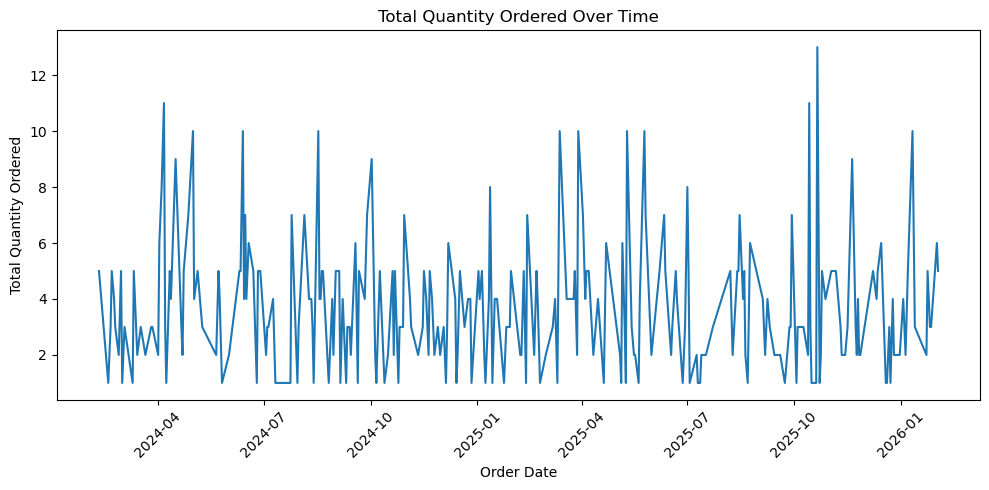

In [106]:
plt.figure(figsize=(10, 5))  # Makes the chart wide enough for dates
plt.plot(prod['order_date'], 
        prod['total_quantity_ordered'])
plt.title('Total Quantity Ordered Over Time')
plt.xlabel('Order Date')
plt.ylabel('Total Quantity Ordered')

plt.xticks(rotation=45)      # Tilts date text so they don't overlap
plt.tight_layout() 

## Simple Expo Model

In [107]:
dt2 = df.copy()
dt2['order_date'] = pd.to_datetime(dt2['order_date'])

### Model for single product

In [108]:
import pandas as pd
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# 1. Isolate the product and define the timeframe
dt_product = dt2[dt2["product_name"] == "Coffee Maker Automatic"].copy()
dt_product['order_date'] = pd.to_datetime(dt_product['order_date'])

start_date = '2024-02-03'
end_date = '2025-06-03'
dt_one_year = dt_product[(dt_product['order_date'] >= start_date) & (dt_product['order_date'] < end_date)]

# 2. Group by both Warehouse ID and Week
# pd.Grouper automatically buckets the dates into weeks within each warehouse group
weekly_wh_orders = dt_one_year.groupby([
    'warehouse_id', 
    pd.Grouper(key='order_date', freq='W-SUN')
])['quantity'].sum().reset_index()

weekly_wh_orders.columns = ['warehouse_id', 'week_end_date', 'total_quantity']

# 3. Iterate through each warehouse to generate individual forecasts
forecast_results = []
FORECAST_STEPS = 4

# Create a continuous weekly date range for the training period
# This is required to identify and fill weeks with exactly 0 sales
full_date_range = pd.date_range(start=start_date, end=end_date, freq='W-SUN')

for warehouse, df_wh in weekly_wh_orders.groupby('warehouse_id'):
    
    # Prepare the time series for the current warehouse
    df_wh = df_wh.set_index('week_end_date')
    
    # CRITICAL: Fill missing weeks with 0. 
    # Without this, low-volume warehouses will have heavily skewed forecasts.
    df_wh = df_wh.reindex(full_date_range, fill_value=0)
    df_wh.index.name = 'week_end_date'
    
    try:
        # Train Simple Exponential Smoothing
        model = SimpleExpSmoothing(df_wh['total_quantity'], initialization_method="estimated")
        fitted_model = model.fit()
        
        # Forecast the next 4 weeks
        predictions = fitted_model.forecast(FORECAST_STEPS)
        
        # Calculate future dates for the predicted weeks
        future_dates = pd.date_range(start=df_wh.index[-1] + pd.Timedelta(days=7), periods=FORECAST_STEPS, freq='W-SUN')
        
        # Store results in a flat structure prepared for database insertion
        for date, pred_val in zip(future_dates, predictions):
            forecast_results.append({
                'warehouse_id': warehouse,
                'forecast_date': date,
                'predicted_total_quantity': max(0, int(round(pred_val))) # Prevent negative forecasts
            })
            
    except Exception as e:
        print(f"Could not fit model for warehouse {warehouse}: {e}")

# 4. Create the final standardized DataFrame ready for MySQL write-back
final_predictions_df = pd.DataFrame(forecast_results)
final_predictions_df

,warehouse_id,forecast_date,predicted_total_quantity
0,10101,2025-06-08,13
1,10101,2025-06-15,13
2,10101,2025-06-22,13
3,10101,2025-06-29,13
4,10108,2025-06-08,13
...,...,...,...
195,50345,2025-06-29,12
196,50350,2025-06-08,13
197,50350,2025-06-15,13
198,50350,2025-06-22,13


In [109]:
# 5. Define the testing window (4 weeks after training ends)
test_start_date = pd.to_datetime('2025-06-03')
test_end_date = test_start_date + pd.DateOffset(weeks=4)

# 6. Filter the original product dataset for the test period
actuals_df = dt_product[(dt_product['order_date'] >= test_start_date) & (dt_product['order_date'] < test_end_date)]

# 7. Group the actuals by Warehouse ID and Week
actual_weekly_wh = actuals_df.groupby([
    'warehouse_id', 
    pd.Grouper(key='order_date', freq='W-SUN')
])['quantity'].sum().reset_index()

actual_weekly_wh.columns = ['warehouse_id', 'forecast_date', 'actual_total_quantity']

# 8. Merge the actuals into your predictions table
# A left merge ensures we keep all predictions, even if a warehouse had 0 actual sales that week
evaluation_df = pd.merge(
    final_predictions_df, 
    actual_weekly_wh, 
    on=['warehouse_id', 'forecast_date'], 
    how='left'
)

# Fill missing actuals with 0 (since no record means 0 orders) and convert to integer
evaluation_df['actual_total_quantity'] = evaluation_df['actual_total_quantity'].fillna(0).astype(int)

# 9. Calculate the error (Difference)
evaluation_df['error'] = evaluation_df['predicted_total_quantity'] - evaluation_df['actual_total_quantity']

evaluation_df

,warehouse_id,forecast_date,predicted_total_quantity,actual_total_quantity,error
0,10101,2025-06-08,13,11,2
1,10101,2025-06-15,13,6,7
2,10101,2025-06-22,13,10,3
3,10101,2025-06-29,13,17,-4
4,10108,2025-06-08,13,12,1
...,...,...,...,...,...
195,50345,2025-06-29,12,17,-5
196,50350,2025-06-08,13,8,5
197,50350,2025-06-15,13,19,-6
198,50350,2025-06-22,13,17,-4


In [110]:

from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Overall Forecast Metrics
y_true = evaluation_df['actual_total_quantity']
y_pred = evaluation_df['predicted_total_quantity']

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

# Calculate WMAPE (Total Absolute Error / Total Actual Demand)
total_actuals = y_true.sum()
total_error = np.abs(y_true - y_pred).sum()

# Prevent division by zero if there were literally 0 sales across all warehouses
wmape = (total_error / total_actuals) * 100 if total_actuals > 0 else 0
overall_accuracy = max(0, 100 - wmape)

print("--- Overall Prototype Accuracy ---")
print(f"MAE (Avg Error): {mae:.2f} units")
print(f"RMSE: {rmse:.2f} units")
print(f"Forecast Accuracy: {overall_accuracy:.2f}%")
print("-" * 30)

# 2. Warehouse-Specific Accuracy (For the Warehouse Managers)
warehouse_metrics = []

for wh_id, group in evaluation_df.groupby('warehouse_id'):
    w_true = group['actual_total_quantity']
    w_pred = group['predicted_total_quantity']
    
    w_mae = mean_absolute_error(w_true, w_pred)
    w_true_sum = w_true.sum()
    w_pred_sum = w_pred.sum()
    w_error = np.abs(w_true - w_pred).sum()
    
    w_wmape = (w_error / w_true_sum) * 100 if w_true_sum > 0 else 0
    w_acc = max(0, 100 - w_wmape)
    
    warehouse_metrics.append({
        'warehouse_id': wh_id,
        'total_actual_demand': w_true_sum,
        'total_predicted_demand': w_pred_sum,
        'MAE': round(w_mae, 2),
        'accuracy_percent': round(w_acc, 2)
    })

wh_accuracy_df = pd.DataFrame(warehouse_metrics).sort_values('accuracy_percent', ascending=False)
print("\n--- Accuracy by Warehouse ---")
wh_accuracy_df

--- Overall Prototype Accuracy ---
MAE (Avg Error): 5.32 units
RMSE: 6.65 units
Forecast Accuracy: 57.26%
------------------------------

--- Accuracy by Warehouse ---


,warehouse_id,total_actual_demand,total_predicted_demand,MAE,accuracy_percent
22,20633,47,48,1.25,89.36
17,20516,53,52,1.75,86.79
24,20647,59,48,2.75,81.36
2,10129,62,52,3.00,80.65
43,41034,52,52,3.00,76.92
18,20519,42,52,2.50,76.19
14,20446,50,48,3.00,76.00
39,30927,56,48,3.50,75.00
34,20849,62,48,4.00,74.19
48,50345,48,48,3.50,70.83


### Data fetching from database

In [ ]:

def fetch_data() :
    # Database credentials
    DB_HOST = "inventory-airy-moon.sage.cloud.layerbase.dev"
    DB_PORT = 22316
    DB_USER = "tanay"
    DB_PASSWORD = "123"
    DB_NAME = "ITDETAILS"

    engine = None
    try:
        # Establish connection
        engine = create_engine(
            f"mysql+pymysql://{quote_plus(DB_USER)}:"
            f"{quote_plus(DB_PASSWORD)}@"
            f"{DB_HOST}:{DB_PORT}/{DB_NAME}",
            pool_pre_ping=True
        )
        with engine.connect() as connection:
            try:
                with open(os.path.join("sql","queries","model_training_data.sql"), "r", encoding="utf-8") as file:
                    query = file.read()
                    df = pd.read_sql(text(query),connection)
                    return df
                
            except Exception as e:
                print(f"Error fetching data: {e}")
                raise
            
    except Exception as e:
        print(f"Error fetching data: {e}")
        raise

    finally:
        if engine is not None:
            engine.dispose()

df=fetch_data()
display(df)  ## When the data will be available, use this dataframe as input for the models

,order_date,order_id,product_id,product_name,warehouse_id,inventory_id,quantity


### Model for all products

In [113]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# 1. Define the timeframe for the entire dataset (no product filter)
start_date = '2024-02-03'
end_date = '2025-06-03'

# Ensure datetime format and filter the full dataset (dt2)
dt2['order_date'] = pd.to_datetime(dt2['order_date'])
dt_timeframe = dt2[(dt2['order_date'] >= start_date) & (dt2['order_date'] < end_date)].copy()

# 2. Group by Product, Warehouse ID, and Week
weekly_orders = dt_timeframe.groupby([
    'product_id',   # Included for database relational mapping 
    'warehouse_id', 
    pd.Grouper(key='order_date', freq='W-SUN')
])['quantity'].sum().reset_index()

weekly_orders.columns = ['product_id', 'warehouse_id', 'week_end_date', 'total_quantity']

# 3. Iterate through every Product-Warehouse combination
forecast_results = []
FORECAST_STEPS = 4

# Create a continuous weekly date range to identify missing sales weeks
full_date_range = pd.date_range(start=start_date, end=end_date, freq='W-SUN')

# Group by the unique combinations of product and warehouse
for (p_id, w_id), df_group in weekly_orders.groupby(['product_id', 'warehouse_id']):
    
    df_group = df_group.set_index('week_end_date')
    
    # Fill missing weeks with 0 for this specific product at this specific warehouse
    df_group = df_group.reindex(full_date_range, fill_value=0)
    df_group.index.name = 'week_end_date'
    
    try:
        # Train Simple Exponential Smoothing
        model = SimpleExpSmoothing(df_group['total_quantity'], initialization_method="estimated")
        fitted_model = model.fit()
        
        # Forecast the next 4 weeks
        predictions = fitted_model.forecast(FORECAST_STEPS)
        future_dates = pd.date_range(start=df_group.index[-1] + pd.Timedelta(days=7), periods=FORECAST_STEPS, freq='W-SUN')
        
        # Store results in a flat structure prepared for database insertion
        for date, pred_val in zip(future_dates, predictions):
            forecast_results.append({
                'product_id': p_id,
                'warehouse_id': w_id,
                'forecast_date': date,
                'predicted_demand': max(0, int(round(pred_val))) 
            })
            
    except Exception as e:
        # Using 'pass' instead of 'print(e)' to prevent console spam 
        # if a few highly sparse items fail to fit out of thousands of combinations.
        pass

# 4. Create the final standardized DataFrame ready for MySQL write-back
final_predictions_df = pd.DataFrame(forecast_results)

final_predictions_df

c:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge

,product_id,warehouse_id,forecast_date,predicted_demand
0,1,10101,2025-06-08,13
1,1,10101,2025-06-15,13
2,1,10101,2025-06-22,13
3,1,10101,2025-06-29,13
4,1,10108,2025-06-08,13
...,...,...,...,...
9595,48,50345,2025-06-29,13
9596,48,50350,2025-06-08,13
9597,48,50350,2025-06-15,13
9598,48,50350,2025-06-22,13


In [114]:
final_predictions_df["predicted_demand"].value_counts()

predicted_demand
13    2880
12    2432
10    1016
14    1008
9      964
11     768
8      236
15     176
16      48
17      28
7       28
18      12
6        4
Name: count, dtype: int64